In [23]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [24]:
# List of paths with .csv files
folder_names  = [
        "/mnt/c/users/helen/Desktop/U2OS_WT",
        "/mnt/c/users/helen/Desktop/U2OS_As_2h",
        "/mnt/c/users/helen/Desktop/U2OS_As_4h",
]

folders = [Path(f) for f in folder_names]

In [ ]:
# Data loading into single dataframe
dfs = []

for folder in folders:
    for file in folder.glob("*.csv"):

        df = pd.read_csv(file)

        # Add file name column
        df["file_name"] = file.stem

        dfs.append(df)

    # Combine all dataframes
    data = pd.concat(dfs, ignore_index=True)

    # Column ordering
    data = data[
        ["file_name", "ROI", "Area", "Mean"]
    ]

    # Rename ROI column to remove the suffix after the underscore
    data["ROI"] = data["ROI"].apply(lambda x: x.split("_")[0])
    
# Add new sample_name column
data['sample_name'] = data['file_name'].apply(lambda x: 'WT' if 'NO_AS' in x else ('Sodium_arsenite_2h' if '2h' in x else 'Sodium_arsenite_4h'))

In [29]:
# Optional: Save the combined dataframe to a new CSV file
data.to_csv("/mnt/c/users/helen/Desktop/combined_data.csv", index=False, sep=";", decimal=",")

In [34]:
data.head()

,file_name,ROI,Area,Mean,sample_name
0,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Nucleus,283.320,2.998,WT
1,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Whole,1186.204,0.821,WT
2,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Cytoplasm,903.206,0.138,WT
3,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Nucleus,249.577,27.742,WT
4,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Whole,545.672,15.616,WT


In [36]:
# Brief statistical summary of the data
data.groupby(['sample_name', 'ROI']).agg({'Area': ['mean', 'std', 'count'], 'Mean': ['mean', 'std']})

Area                        Mean  \
                                    mean         std count      mean   
sample_name        ROI                                                 
Sodium_arsenite_2h Cytoplasm  560.791880  260.854993    25  1.255640   
                   Nucleus    217.539480   84.280695    25  5.869080   
                   Whole      775.838320  303.297478    25  2.801800   
Sodium_arsenite_4h Cytoplasm  559.655679  250.844670    28  2.976536   
                   Nucleus    276.630714  117.084075    28  8.305357   
                   Whole      818.029321  338.667682    28  4.502286   
WT                 Cytoplasm  542.226931  351.358621    29  1.226414   
                   Nucleus    245.328552   71.908698    29  7.576552   
                   Whole      772.272379  394.548491    29  3.218793   

                                         
                                    std  
sample_name        ROI                   
Sodium_arsenite_2h Cytoplasm   1.324545  
                   Nucleus     7.193952  
                   Whole       3.612417  
Sodium_arsenite_4h Cytoplasm   5.061174  
                   Nucleus     8.417169  
                   Whole       5.911555  
WT                 Cytoplasm   1.304359  
                   Nucleus    10.381531  
                   Whole       4.055540

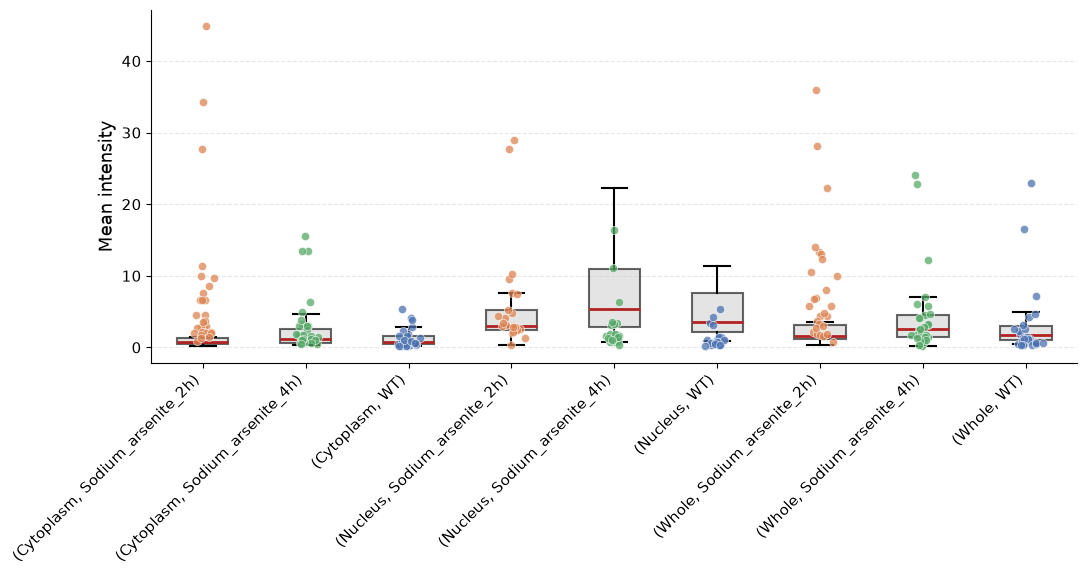

In [46]:
fig, ax = plt.subplots(figsize=(11, 6))

# Boxplot
data.boxplot(
    column="Mean",
    by=["ROI", "sample_name"],
    ax=ax,
    grid=False,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray",
                  edgecolor="black",
                  linewidth=1.5,
                  alpha=0.6),
    medianprops=dict(color="firebrick", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

# -------------------------------------------------------
# Color boxes according to ROI
# -------------------------------------------------------
roi_colors = {
    "Cytoplasm": "#4C72B0",   # blue
    "Nucleus": "#DD8452",     # orange
    "Whole": "#55A868",       # green
}


# -------------------------------------------------------
# Overlay individual points
# -------------------------------------------------------

# Add individual points (jitter)
groups = data.groupby(["ROI", "sample_name"], sort=False)

for i, ((roi, sample), group) in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(group))
    ax.scatter(
        x,
        group["Mean"],
        color=roi_colors[roi],
        s=35,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )

# Labels
ax.set_xlabel("")
ax.set_ylabel("Mean intensity", fontsize=13)

# Rotate x-axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Remove automatic pandas title
plt.suptitle("")
ax.set_title("")

# Improve appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()